# PatchSAE Demo

In [1]:
from src.demo.core import SAETester
from tasks.utils import (
    get_all_classnames,
    get_max_acts_and_images,
    get_sae_and_vit,
    load_datasets,
)

/home/sunayana/miniconda3/envs/patchsae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from transformers import CLIPModel

root = "out/feature_data"
sae_runname = "sae_base"
vit_name = "base"
device =  "cpu"
# ------------------------ base ------------------------
sae_path = "/home/sunayana/Documents/Concept_LoRA/patchsae/out/checkpoints/medmnist/d2ygd3bb/final_sparse_autoencoder_openai/clip-vit-base-patch16_-2_resid_49152.pt"
sae, vit, cfg = get_sae_and_vit(
    sae_path=sae_path,
    vit_type="base", # Ensure this matches ViT-B/16
    device=device,
    backbone="openai/clip-vit-base-patch16", 
    model_path=None,
    classnames=None,
)

# 2. Load your merged LoRA weights
merged_weights_path = "/home/sunayana/Documents/Concept_LoRA/lora_merged/clip_vitb16_medmnist_lora_merged.pt"
print(f"Loading merged LoRA weights from {merged_weights_path}...")

state_dict = torch.load(merged_weights_path, map_location=device)

datasets = load_datasets()
max_act_imgs, mean_acts = get_max_acts_and_images(datasets, root, sae_runname, vit_name)

# ------------------------ maple ------------------------
# sae_path = "data/sae_weight/base/out.pt"
# config_path = "configs/models/maple/vit_b16_c2_ep5_batch4_2ctx.yaml"
# model_path="data/clip/maple/imagenet/model.pth.tar-2"
# sae, vit, cfg = get_sae_and_vit(sae_path=sae_path, vit_type='maple', device='cpu', model_path=model_path,config_path=config_path, backbone='openai/clip-vit-base-patch16', classnames=classnames["imagenet"])
# max_act_imgs, mean_acts = get_max_acts_and_images(datasets, root, sae_runname, vit_name)

Loading merged LoRA weights from /home/sunayana/Documents/Concept_LoRA/lora_merged/clip_vitb16_medmnist_lora_merged.pt...


In [3]:
# Check SAE floating‑point precision
import torch

print("=== SAE parameter dtypes ===")
unique_param_dtypes = set()
for name, param in sae.named_parameters():
    unique_param_dtypes.add(param.dtype)
    print(f"{name}: shape={tuple(param.shape)}, dtype={param.dtype}")

print("\nUnique SAE param dtypes:", unique_param_dtypes)

print("\n=== SAE buffer dtypes ===")
unique_buffer_dtypes = set()
for name, buf in sae.named_buffers():
    unique_buffer_dtypes.add(buf.dtype)
    print(f"{name}: shape={tuple(buf.shape)}, dtype={buf.dtype}")
print("\nUnique SAE buffer dtypes:", unique_buffer_dtypes)

=== SAE parameter dtypes ===
W_enc: shape=(768, 49152), dtype=torch.float32
b_enc: shape=(49152,), dtype=torch.float32
W_dec: shape=(49152, 768), dtype=torch.float32
b_dec: shape=(768,), dtype=torch.float32

Unique SAE param dtypes: {torch.float32}

=== SAE buffer dtypes ===

Unique SAE buffer dtypes: set()


In [4]:
# ...existing code...
state_dict = torch.load(merged_weights_path, map_location=device)

# Try to load whatever matches, but don't crash
incomp = vit.model.load_state_dict(state_dict, strict=False)

print("\n=== Incompatible keys when loading LoRA checkpoint into HF CLIPModel ===")
print("Missing keys (first 10):", incomp.missing_keys[:10])
print("Unexpected keys (first 10):", incomp.unexpected_keys[:10])
print("Total missing:", len(incomp.missing_keys), " Total unexpected:", len(incomp.unexpected_keys))
# ...existing code...


=== Incompatible keys when loading LoRA checkpoint into HF CLIPModel ===
Missing keys (first 10): ['text_model.embeddings.token_embedding.weight', 'text_model.embeddings.position_embedding.weight', 'text_model.encoder.layers.0.self_attn.k_proj.weight', 'text_model.encoder.layers.0.self_attn.k_proj.bias', 'text_model.encoder.layers.0.self_attn.v_proj.weight', 'text_model.encoder.layers.0.self_attn.v_proj.bias', 'text_model.encoder.layers.0.self_attn.q_proj.weight', 'text_model.encoder.layers.0.self_attn.q_proj.bias', 'text_model.encoder.layers.0.self_attn.out_proj.weight', 'text_model.encoder.layers.0.self_attn.out_proj.bias']
Unexpected keys (first 10): ['positional_embedding', 'visual.class_embedding', 'visual.positional_embedding', 'visual.proj', 'visual.conv1.weight', 'visual.ln_pre.weight', 'visual.ln_pre.bias', 'visual.transformer.resblocks.0.attn.in_proj_weight', 'visual.transformer.resblocks.0.attn.in_proj_bias', 'visual.transformer.resblocks.0.attn.out_proj.weight']
Total miss

In [7]:
import torch
from collections import OrderedDict

def convert_openai_to_hf_clip(openai_state_dict):
    """
    Convert full OpenAI CLIP state dict to HuggingFace CLIP format
    Handles both vision and text models
    """
    hf_state_dict = OrderedDict()
    
    for key, value in openai_state_dict.items():
        new_key = None
        
        # Handle vision model keys
        if key.startswith('visual.'):
            new_key = key.replace('visual.', 'vision_model.')
            
            # Patch embedding
            new_key = new_key.replace('vision_model.conv1.', 'vision_model.embeddings.patch_embedding.')
            
            # Class and position embeddings
            if new_key == 'vision_model.class_embedding':
                new_key = 'vision_model.embeddings.class_embedding'
            elif new_key == 'vision_model.positional_embedding':
                new_key = 'vision_model.embeddings.position_embedding.weight'
            
            # Pre/post layer norms
            new_key = new_key.replace('vision_model.ln_pre.', 'vision_model.pre_layrnorm.')
            new_key = new_key.replace('vision_model.ln_post.', 'vision_model.post_layernorm.')
            
            # Transformer blocks
            new_key = new_key.replace('vision_model.transformer.resblocks.', 'vision_model.encoder.layers.')
            
            # Attention layers
            if '.attn.in_proj_weight' in new_key:
                # Split combined QKV weight
                layer_num = new_key.split('encoder.layers.')[1].split('.')[0]
                base = f'vision_model.encoder.layers.{layer_num}.self_attn.'
                dim = value.shape[0] // 3
                hf_state_dict[base + 'q_proj.weight'] = value[:dim].clone()
                hf_state_dict[base + 'k_proj.weight'] = value[dim:2*dim].clone()
                hf_state_dict[base + 'v_proj.weight'] = value[2*dim:].clone()
                continue
            elif '.attn.in_proj_bias' in new_key:
                # Split combined QKV bias
                layer_num = new_key.split('encoder.layers.')[1].split('.')[0]
                base = f'vision_model.encoder.layers.{layer_num}.self_attn.'
                dim = value.shape[0] // 3
                hf_state_dict[base + 'q_proj.bias'] = value[:dim].clone()
                hf_state_dict[base + 'k_proj.bias'] = value[dim:2*dim].clone()
                hf_state_dict[base + 'v_proj.bias'] = value[2*dim:].clone()
                continue
            
            new_key = new_key.replace('.attn.out_proj.', '.self_attn.out_proj.')
            
            # MLP layers
            new_key = new_key.replace('.mlp.c_fc.', '.mlp.fc1.')
            new_key = new_key.replace('.mlp.c_proj.', '.mlp.fc2.')
            
            # Layer norms
            new_key = new_key.replace('.ln_1.', '.layer_norm1.')
            new_key = new_key.replace('.ln_2.', '.layer_norm2.')
            
            # Vision projection (last layer)
            if new_key == 'vision_model.proj':
                new_key = 'visual_projection.weight'
                value = value.T  # OpenAI uses transposed projection
        
        # Handle text model keys
        elif key.startswith('transformer.') or key in ['token_embedding.weight', 'positional_embedding', 
                                                         'ln_final.weight', 'ln_final.bias', 'text_projection']:
            # Token and position embeddings
            if key == 'token_embedding.weight':
                new_key = 'text_model.embeddings.token_embedding.weight'
            elif key == 'positional_embedding':
                new_key = 'text_model.embeddings.position_embedding.weight'
            
            # Transformer blocks
            elif key.startswith('transformer.resblocks.'):
                new_key = key.replace('transformer.resblocks.', 'text_model.encoder.layers.')
                
                # Attention layers
                if '.attn.in_proj_weight' in new_key:
                    layer_num = new_key.split('encoder.layers.')[1].split('.')[0]
                    base = f'text_model.encoder.layers.{layer_num}.self_attn.'
                    dim = value.shape[0] // 3
                    hf_state_dict[base + 'q_proj.weight'] = value[:dim].clone()
                    hf_state_dict[base + 'k_proj.weight'] = value[dim:2*dim].clone()
                    hf_state_dict[base + 'v_proj.weight'] = value[2*dim:].clone()
                    continue
                elif '.attn.in_proj_bias' in new_key:
                    layer_num = new_key.split('encoder.layers.')[1].split('.')[0]
                    base = f'text_model.encoder.layers.{layer_num}.self_attn.'
                    dim = value.shape[0] // 3
                    hf_state_dict[base + 'q_proj.bias'] = value[:dim].clone()
                    hf_state_dict[base + 'k_proj.bias'] = value[dim:2*dim].clone()
                    hf_state_dict[base + 'v_proj.bias'] = value[2*dim:].clone()
                    continue
                
                new_key = new_key.replace('.attn.out_proj.', '.self_attn.out_proj.')
                new_key = new_key.replace('.mlp.c_fc.', '.mlp.fc1.')
                new_key = new_key.replace('.mlp.c_proj.', '.mlp.fc2.')
                new_key = new_key.replace('.ln_1.', '.layer_norm1.')
                new_key = new_key.replace('.ln_2.', '.layer_norm2.')
            
            # Final layer norm
            elif key.startswith('ln_final.'):
                new_key = key.replace('ln_final.', 'text_model.final_layer_norm.')
            
            # Text projection
            elif key == 'text_projection':
                new_key = 'text_projection.weight'
                value = value.T  # OpenAI uses transposed projection
        
        # Logit scale (shared parameter)
        elif key == 'logit_scale':
            new_key = 'logit_scale'
        
        # Add to output dict
        if new_key:
            hf_state_dict[new_key] = value
        else:
            print(f"Warning: Unhandled key: {key}")
    
    return hf_state_dict

# Load and convert
state_dict = torch.load(merged_weights_path, map_location=device)
print(f"Loaded {len(state_dict)} keys from checkpoint")

# Convert to HuggingFace format
hf_state_dict = convert_openai_to_hf_clip(state_dict)
print(f"Converted to {len(hf_state_dict)} HuggingFace keys")

# Load into model
incomp = vit.model.load_state_dict(hf_state_dict)

print("\n=== Incompatible keys when loading LoRA checkpoint into HF CLIPModel ===")
print("Missing keys (first 10):", incomp.missing_keys[:10])
print("Unexpected keys (first 10):", incomp.unexpected_keys[:10])
print("Total missing:", len(incomp.missing_keys), "Total unexpected:", len(incomp.unexpected_keys))

# Debug: Show some conversions
print("\n=== Sample key conversions ===")
openai_keys = list(state_dict.keys())[:10]
for ok in openai_keys:
    # Find corresponding HF key
    print(f"OpenAI: {ok}")
    # This is just for display - actual conversion happens in the function
    
    


Loaded 302 keys from checkpoint
Converted to 398 HuggingFace keys

=== Incompatible keys when loading LoRA checkpoint into HF CLIPModel ===
Missing keys (first 10): []
Unexpected keys (first 10): []
Total missing: 0 Total unexpected: 0

=== Sample key conversions ===
OpenAI: positional_embedding
OpenAI: text_projection
OpenAI: logit_scale
OpenAI: visual.class_embedding
OpenAI: visual.positional_embedding
OpenAI: visual.proj
OpenAI: visual.conv1.weight
OpenAI: visual.ln_pre.weight
OpenAI: visual.ln_pre.bias
OpenAI: visual.transformer.resblocks.0.attn.in_proj_weight


In [8]:
classnames = get_all_classnames(datasets, data_root="configs/classnames")
sae_clip = SAETester(vit, cfg, sae, mean_acts, max_act_imgs, datasets, classnames)

In [9]:
# After conversion, before loading
hf_state_dict = convert_openai_to_hf_clip(state_dict)
print(f"Converted to {len(hf_state_dict)} HuggingFace keys")

# Check if vision model weights are actually in the converted dict
vision_keys = [k for k in hf_state_dict.keys() if 'vision_model' in k]
print(f"Number of vision_model keys: {len(vision_keys)}")
print("Sample vision keys:", vision_keys[:5])

# Check a specific weight that should differ
if 'vision_model.encoder.layers.0.self_attn.q_proj.weight' in hf_state_dict:
    print("✓ q_proj.weight found in converted dict")
    print(f"  Shape: {hf_state_dict['vision_model.encoder.layers.0.self_attn.q_proj.weight'].shape}")
else:
    print("✗ q_proj.weight NOT found in converted dict")

Converted to 398 HuggingFace keys
Number of vision_model keys: 199
Sample vision keys: ['vision_model.embeddings.class_embedding', 'vision_model.embeddings.position_embedding.weight', 'vision_model.embeddings.patch_embedding.weight', 'vision_model.pre_layrnorm.weight', 'vision_model.pre_layrnorm.bias']
✓ q_proj.weight found in converted dict
  Shape: torch.Size([768, 768])


In [10]:
# Before conversion
state_dict = torch.load(merged_weights_path, map_location=device)

# Check what's in the original checkpoint
print("Keys in checkpoint:")
for i, k in enumerate(list(state_dict.keys())[:20]):
    print(f"  {k}: {state_dict[k].shape}")

# Check if it has visual.transformer keys (OpenAI format)
visual_keys = [k for k in state_dict.keys() if 'visual' in k]
print(f"\nVisual keys in checkpoint: {len(visual_keys)}")

Keys in checkpoint:
  positional_embedding: torch.Size([77, 512])
  text_projection: torch.Size([512, 512])
  logit_scale: torch.Size([])
  visual.class_embedding: torch.Size([768])
  visual.positional_embedding: torch.Size([197, 768])
  visual.proj: torch.Size([768, 512])
  visual.conv1.weight: torch.Size([768, 3, 16, 16])
  visual.ln_pre.weight: torch.Size([768])
  visual.ln_pre.bias: torch.Size([768])
  visual.transformer.resblocks.0.attn.in_proj_weight: torch.Size([2304, 768])
  visual.transformer.resblocks.0.attn.in_proj_bias: torch.Size([2304])
  visual.transformer.resblocks.0.attn.out_proj.weight: torch.Size([768, 768])
  visual.transformer.resblocks.0.attn.out_proj.bias: torch.Size([768])
  visual.transformer.resblocks.0.ln_1.weight: torch.Size([768])
  visual.transformer.resblocks.0.ln_1.bias: torch.Size([768])
  visual.transformer.resblocks.0.mlp.c_fc.weight: torch.Size([3072, 768])
  visual.transformer.resblocks.0.mlp.c_fc.bias: torch.Size([3072])
  visual.transformer.resblo

In [11]:
# Load into model with detailed tracking
incomp = vit.model.load_state_dict(hf_state_dict, strict=False)

print(f"\nMissing: {len(incomp.missing_keys)}")
print(f"Unexpected: {len(incomp.unexpected_keys)}")

# CRITICAL: Check if the key we're testing was actually loaded
test_key = 'vision_model.encoder.layers.0.self_attn.q_proj.weight'
if test_key in incomp.missing_keys:
    print(f"⚠️ WARNING: {test_key} was NOT loaded (in missing_keys)!")
else:
    print(f"✓ {test_key} should have been loaded")

# Verify weight actually changed after loading
with torch.no_grad():
    current_weight = vit.model.vision_model.encoder.layers[0].self_attn.q_proj.weight
    if test_key in hf_state_dict:
        expected_weight = hf_state_dict[test_key]
        diff = (current_weight - expected_weight).abs().max().item()
        print(f"Diff between loaded and expected: {diff}")


Missing: 0
Unexpected: 0
✓ vision_model.encoder.layers.0.self_attn.q_proj.weight should have been loaded
Diff between loaded and expected: 0.0


In [12]:
# Simpler check: Compare checkpoint to HuggingFace base
from transformers import CLIPModel

# Load a fresh base model
base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)

# Check the converted checkpoint weights against base
print("="*80)
print("COMPARING CHECKPOINT TO BASE MODEL")
print("="*80)

# Get a few sample weights to compare
test_layers = [
    'vision_model.encoder.layers.0.self_attn.q_proj.weight',
    'vision_model.encoder.layers.0.self_attn.k_proj.weight',
    'vision_model.encoder.layers.5.mlp.fc1.weight',
    'vision_model.embeddings.patch_embedding.weight',
]

print("\nChecking if checkpoint weights differ from base:")
any_difference = False

for key in test_layers:
    if key in hf_state_dict:
        checkpoint_weight = hf_state_dict[key]
        base_weight = base_model.state_dict()[key]
        
        diff = (checkpoint_weight - base_weight).abs().max().item()
        mean_diff = (checkpoint_weight - base_weight).abs().mean().item()
        
        print(f"\n{key}:")
        print(f"  Max diff: {diff:.8f}")
        print(f"  Mean diff: {mean_diff:.8f}")
        
        if diff > 1e-6:
            print(f"  ✓ DIFFERS from base!")
            any_difference = True
        else:
            print(f"  ✗ Identical to base")
    else:
        print(f"\n{key}: NOT FOUND in checkpoint")

print("\n" + "="*80)
if any_difference:
    print("RESULT: ✓ Checkpoint contains LoRA-modified weights")
else:
    print("RESULT: ❌ Checkpoint is IDENTICAL to base model")
    print("\nPossible causes:")
    print("1. LoRA was never trained")
    print("2. LoRA adapters weren't merged with base weights")
    print("3. You're loading the wrong checkpoint file")
print("="*80)

# Also check the original state_dict before conversion
print("\n\nORIGINAL CHECKPOINT INFO:")
print(f"Checkpoint path: {merged_weights_path}")
print(f"Number of keys: {len(state_dict)}")
print(f"\nFirst 20 keys:")
for i, k in enumerate(list(state_dict.keys())[:20]):
    print(f"  {i+1}. {k}: shape {state_dict[k].shape}")

# Check if these are LoRA adapter keys or merged weights
has_lora_adapters = any('lora' in k.lower() for k in state_dict.keys())
print(f"\nHas LoRA adapter keys: {has_lora_adapters}")

if has_lora_adapters:
    print("\n⚠️ WARNING: Your checkpoint contains LoRA ADAPTERS, not MERGED weights!")
    print("You need to merge them first. What keys do you see?")
    lora_keys = [k for k in state_dict.keys() if 'lora' in k.lower()]
    print(f"LoRA keys sample: {lora_keys[:5]}")

COMPARING CHECKPOINT TO BASE MODEL

Checking if checkpoint weights differ from base:

vision_model.encoder.layers.0.self_attn.q_proj.weight:
  Max diff: 0.00164795
  Mean diff: 0.00011561
  ✓ DIFFERS from base!

vision_model.encoder.layers.0.self_attn.k_proj.weight:
  Max diff: 0.00113678
  Mean diff: 0.00009932
  ✓ DIFFERS from base!

vision_model.encoder.layers.5.mlp.fc1.weight:
  Max diff: 0.00000000
  Mean diff: 0.00000000
  ✗ Identical to base

vision_model.embeddings.patch_embedding.weight:
  Max diff: 0.00000000
  Mean diff: 0.00000000
  ✗ Identical to base

RESULT: ✓ Checkpoint contains LoRA-modified weights


ORIGINAL CHECKPOINT INFO:
Checkpoint path: /home/sunayana/Documents/Concept_LoRA/lora_merged/clip_vitb16_medmnist_lora_merged.pt
Number of keys: 302

First 20 keys:
  1. positional_embedding: shape torch.Size([77, 512])
  2. text_projection: shape torch.Size([512, 512])
  3. logit_scale: shape torch.Size([])
  4. visual.class_embedding: shape torch.Size([768])
  5. visual

In [13]:
# ...existing code...
classnames = get_all_classnames(datasets, data_root="configs/classnames")
sae_clip = SAETester(vit, cfg, sae, mean_acts, max_act_imgs, datasets, classnames)

# ---- Debug 1: make sure SAETester holds the same vit object ----
print("sae_clip.vit is vit:", sae_clip.vit is vit)
print("sae_clip.vit.model is vit.model:", sae_clip.vit.model is vit.model)

# ---- Debug 2: check that LoRA actually changed weights vs a fresh base model ----
from transformers import CLIPModel

base_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
base_model.eval()

with torch.no_grad():
    w_base = base_model.vision_model.encoder.layers[0].self_attn.q_proj.weight
    w_lora = vit.model.vision_model.encoder.layers[0].self_attn.q_proj.weight
    max_diff = (w_base - w_lora).abs().max().item()
    print("Max |diff| in vision layer0.q_proj vs base:", max_diff)
# ...existing code...

sae_clip.vit is vit: True
sae_clip.vit.model is vit.model: True
Max |diff| in vision layer0.q_proj vs base: 0.00164794921875


In [ ]:
# image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
# image_url = "data/image/sun-alley.jpg"
image_url = "/home/sunayana/Documents/Concept_LoRA/data/pathmnist_imagefolder/cancer-associated_stroma/train_000032.png"


sae_clip.register_image(image_url)

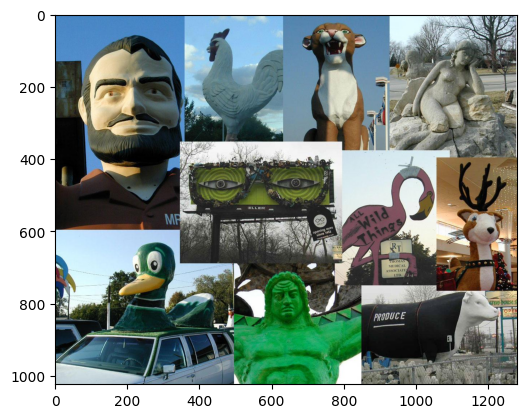

In [15]:
sae_clip.show_input_image()

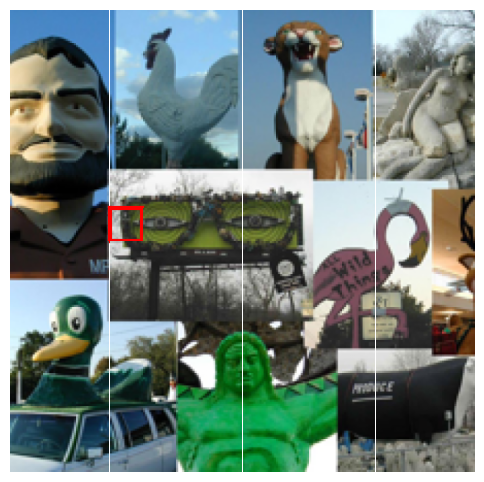

Union of top 2 neurons: [24448 19273]


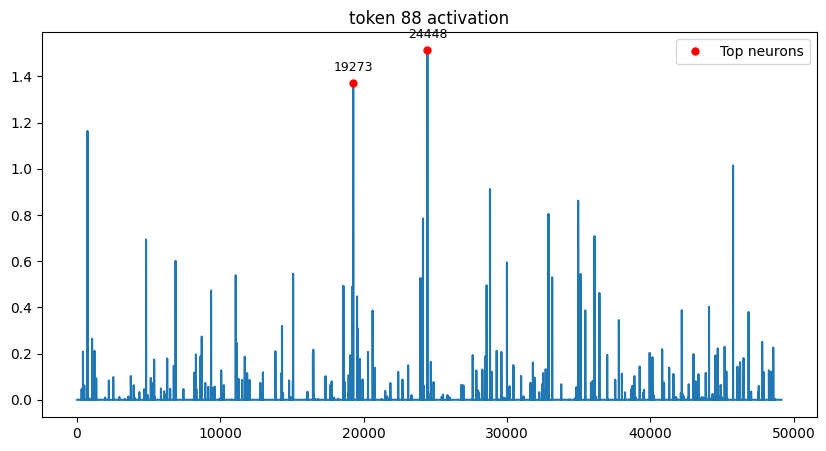

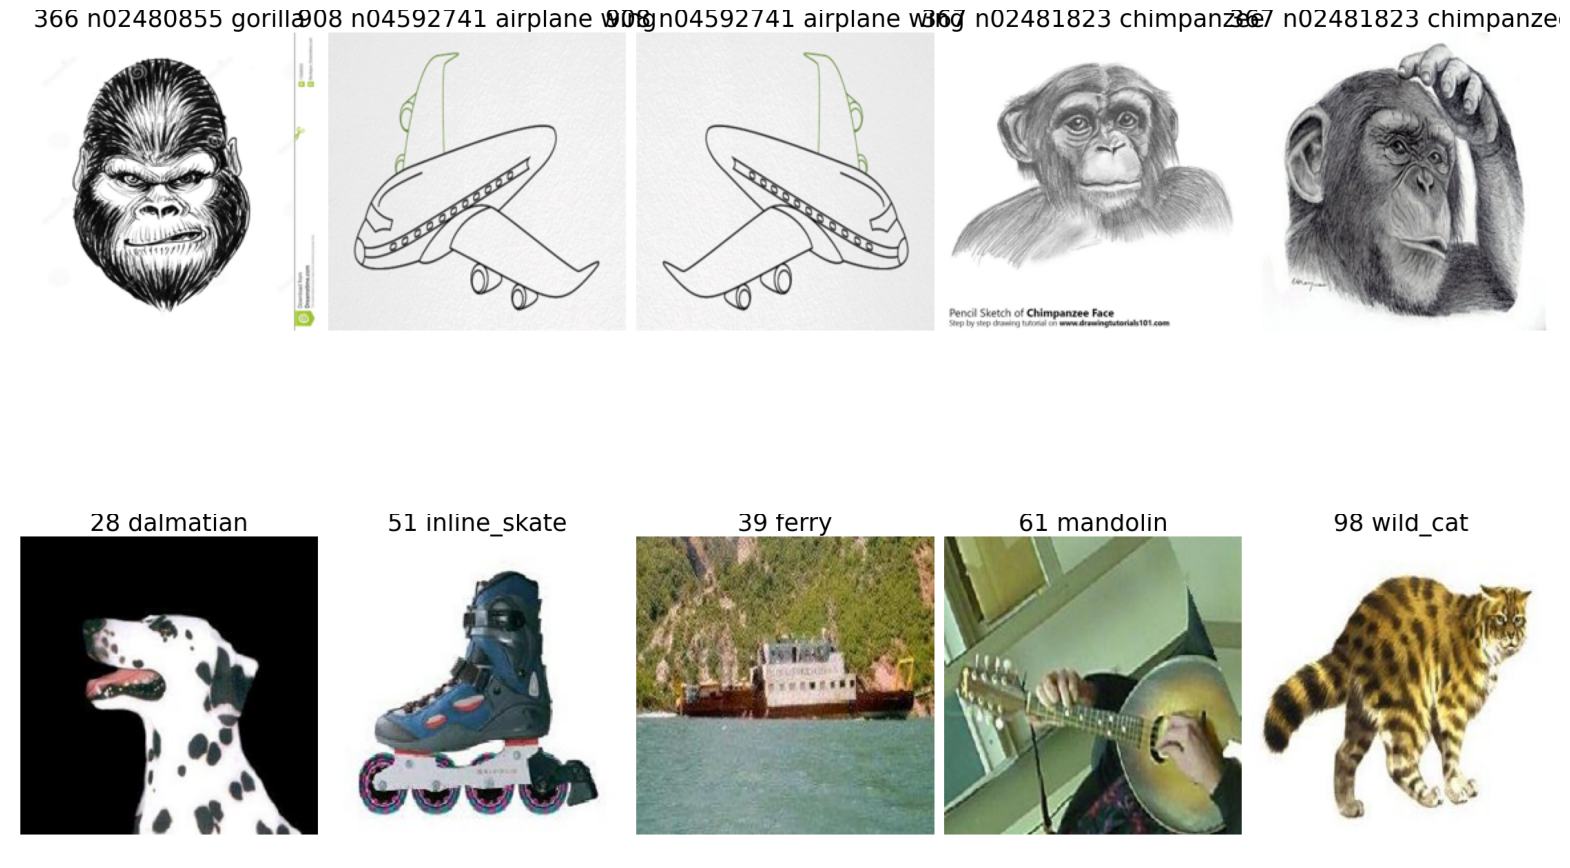

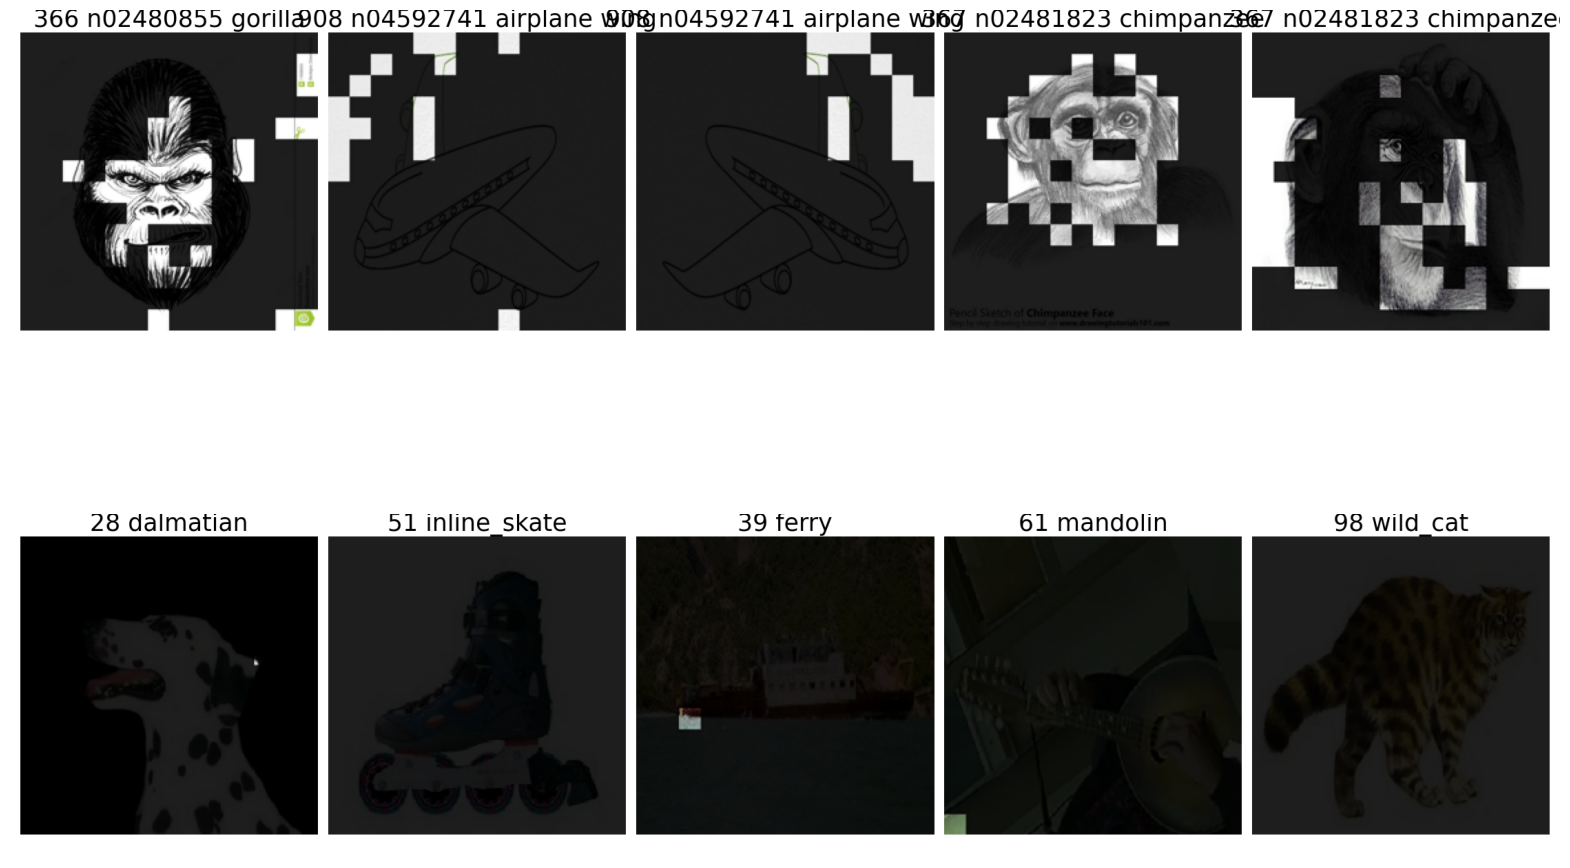

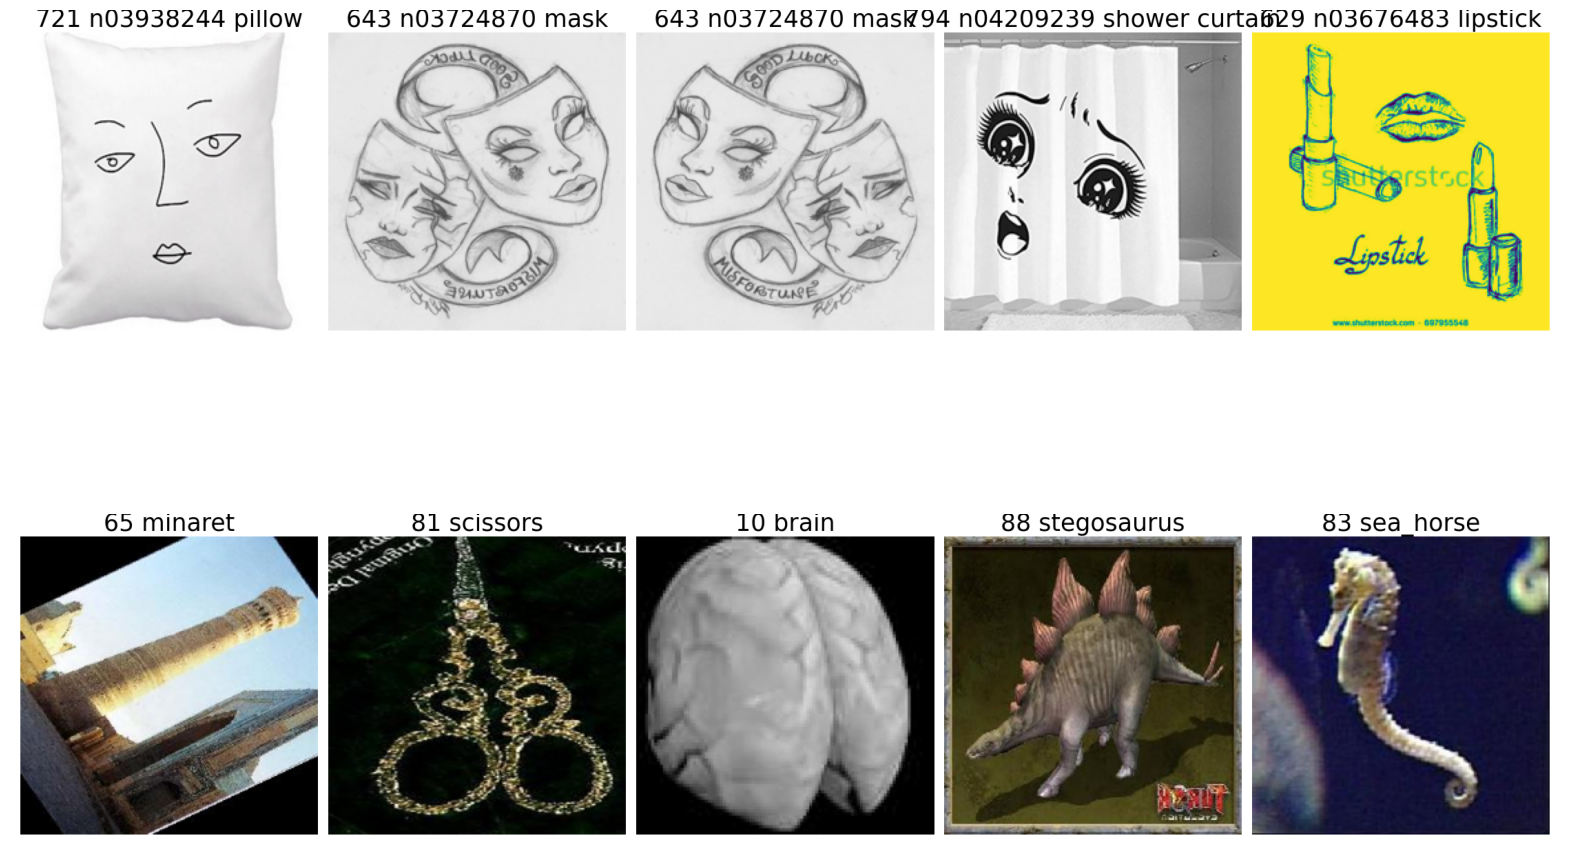

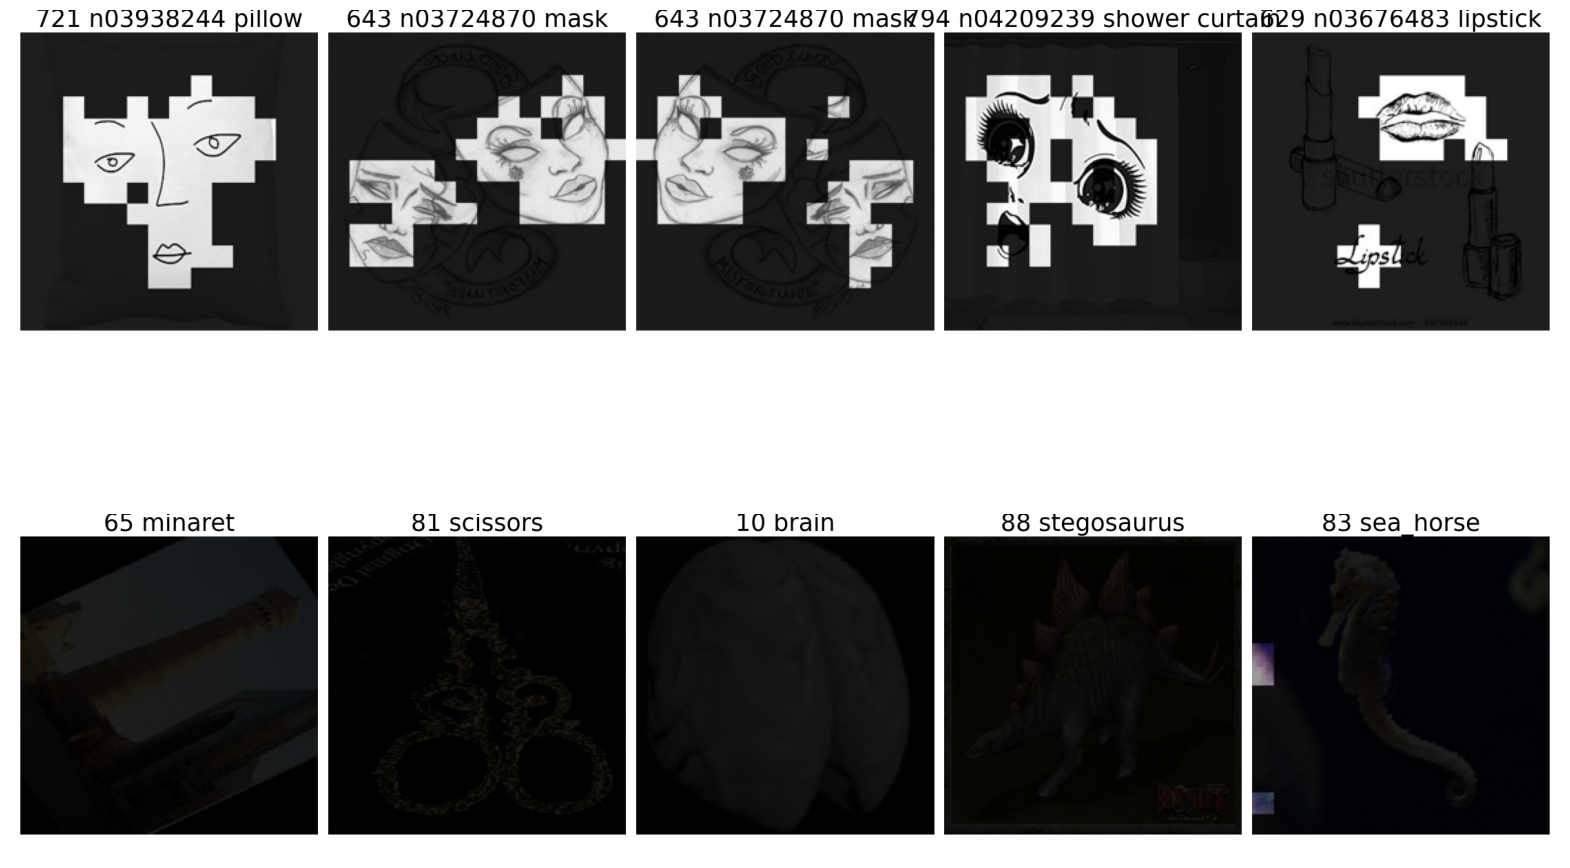

In [15]:
sae_clip.run(highlight_patch_idx=88, top_k=2, num_images=5)
